# **Installs**

In [ ]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip walmart-recruiting-store-sales-forecasting

#unzip the zip
!unzip train.csv.zip
!unzip test.csv.zip
!unzip features.csv.zip

#remove unnecessary zips
!rm train.csv.zip
!rm test.csv.zip
!rm features.csv.zip
!rm walmart-recruiting-store-sales-forecasting.zip

  0% 0.00/2.70M [00:00<?, ?B/s]
100% 2.70M/2.70M [00:00<00:00, 736MB/s]
Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           
Archive:  train.csv.zip
  inflating: train.csv               
Archive:  test.csv.zip
  inflating: test.csv                
Archive:  features.csv.zip
  inflating: features.csv            


In [ ]:
!pip install wandb onnx -Uq

# **Imports**

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import wandb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE
from scipy import stats



# **Data Exploration**

In [ ]:
stores_df = pd.read_csv("stores.csv")
features_df =pd.read_csv("features.csv")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


df = train_df.merge(features_df, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores_df, on="Store", how="left")
df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
train_df.head()

In [ ]:
features_df.head()

In [ ]:
stores_df.head()

**Total Sales**

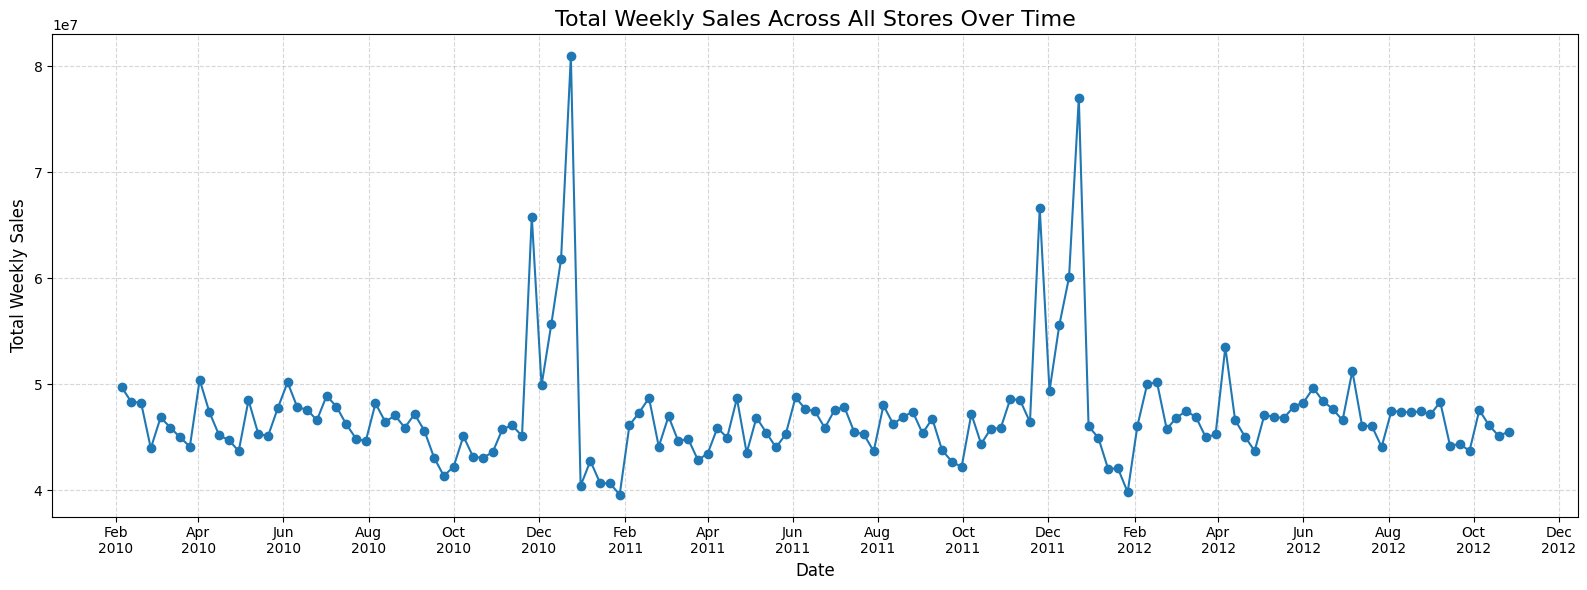

In [ ]:
total_sales_per_date = train_df.groupby("Date")["Weekly_Sales"].sum().reset_index()
total_sales_per_date = total_sales_per_date.sort_values("Date")

total_sales_per_date["Date"] = pd.to_datetime(total_sales_per_date["Date"])


plt.figure(figsize=(16, 6))
plt.plot(total_sales_per_date["Date"], total_sales_per_date["Weekly_Sales"], marker='o', linestyle='-')


plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.title("Total Weekly Sales Across All Stores Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Weekly Sales", fontsize=12)
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()



**Sales per Store**

In [ ]:
store_sales = train_df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
store_sales.plot(kind='bar', figsize=(12, 5), title='Total Sales per Store')
plt.show()


**Sales Per department**

In [ ]:
dept_sales = train_df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)
dept_sales.plot(kind='bar', figsize=(12, 5), title='Total Sales per Department')
plt.show()


**correlation heatmap**

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()


# **Functions**


In [ ]:
def prepare_df_for_nf(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    df_pre = df.copy()
    # Convert Date to datetime and rename to ds
    df_pre['Date'] = pd.to_datetime(df_pre['Date'])
    df_pre.rename(columns={'Date': 'ds'}, inplace=True)

    # Rename Weekly_Sales to y in training; create dummy y in test
    if is_train:
        df_pre.rename(columns={'Weekly_Sales': 'y'}, inplace=True)
    else:
        df_pre['y'] = np.nan

    # Build unique_id per Store-Dept
    df_pre['unique_id'] = (
        df_pre['Dept'].astype(str) + '_' + df_pre['Store'].astype(str)
    )

    return df_pre

In [ ]:
def split_sales_data(df: pd.DataFrame, split_date : pd.Timestamp = pd.Timestamp('2012-02-15')):
    """
    Splits sales data into train and test sets based on a provided date,
    including the 'Weekly_Sales' column in both dataframes.

    Parameters:
    - df (pd.DataFrame): df to be split.
    - split_date (pd.Timestamp): The cutoff date for train-test split.

    Returns:
    - df_train, df_test: Tuple of training and test dataframes including 'Weekly_Sales'.
    """
    # Ensure Date is in datetime format
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])

    train_mask = df['Date'] < split_date
    test_mask = df['Date'] >= split_date

    df_train = df[train_mask].copy()
    df_test = df[test_mask].copy()

    return df_train, df_test

In [ ]:
 # WMAE calculation
def wmae(y_true, y_pred, w):
    """Weighted MAE (holidays count 5×) with NaN handling."""
    # Create mask for finite values
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(w)

    if not mask.any():
        print("⚠️ All values are NaN/infinite in WMAE calculation")
        return np.nan

    # Filter to finite values only
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    w_clean = w[mask]

    if w_clean.sum() == 0:
        print("⚠️ Sum of weights is zero in WMAE calculation")
        return np.nan

    return (w_clean * np.abs(y_true_clean - y_pred_clean)).sum() / w_clean.sum()

In [ ]:
def log_params(model, static_vars: list, dynamic_vars: list):
    """
    Log DLinear hyperparameters and feature lists to W&B.
    Only logs attributes if they exist on the model.
    """
    cfg = {}

    # List of attributes we know DLinear should have
    for attr in [
        "h",
        "input_size",
        "learning_rate",
        "max_steps",
        "val_check_steps",
        "early_stop_patience_steps",
        "moving_avg_window",
        # skip scaler_type if not present
    ]:
        val = getattr(model, attr, None)
        if val is not None:
            cfg[attr] = val

    # Log loss name if available
    loss = getattr(model, "loss", None)
    if loss is not None:
        cfg["loss"] = loss.__class__.__name__

    # Add your feature lists
    cfg["static_vars"]  = static_vars
    cfg["dynamic_vars"] = dynamic_vars

    # Update W&B config
    wandb.config.update(cfg, allow_val_change=True)

In [ ]:
def log_wandb(nf, train_df, val_df, y_val, w_val, split="val"):
    """
    1) Forecast with nf.predict on train_df
    2) Align forecasts to val_df by unique_id and position
    3) Compute MAE, RMSE, WMAE
    4) Log metrics + diagnostic plots to W&B
    """
    # 1) Forecast
    preds_all = nf.predict(df=train_df)

    # 2) Align by mask + positional slicing
    records = []
    for uid in preds_all['unique_id'].unique():
        p = preds_all[preds_all['unique_id'] == uid].sort_values('ds').reset_index(drop=True)
        v = val_df[val_df['unique_id'] == uid].sort_values('ds').reset_index(drop=True)
        if p.empty or v.empty:
            continue
        n = min(len(p), len(v))

        # Create boolean mask over val_df for this uid
        mask = (val_df['unique_id'] == uid).values
        # Extract the first n true values
        y_arr = y_val.values[mask][:n]
        w_arr = w_val[mask][:n]
        ds_arr = v['ds'].iloc[:n].values
        y_pred_arr = p['DLinear'].iloc[:n].values

        # Build temp DataFrame
        records.append(pd.DataFrame({
            'unique_id': uid,
            'ds':         ds_arr,
            'y_true':     y_arr,
            'y_pred':     y_pred_arr,
            'w':          w_arr
        }))

    if not records:
        raise ValueError("No overlapping series for validation.")
    results = pd.concat(records, ignore_index=True)

    # 3) Metrics
    mae  = mean_absolute_error(results['y_true'], results['y_pred'])
    rmse = np.sqrt(mean_squared_error(results['y_true'], results['y_pred']))
    wmae = (results['w'] * np.abs(results['y_true'] - results['y_pred'])).sum() / results['w'].sum()

    wandb.log({f"{split}/MAE": mae, f"{split}/RMSE": rmse, f"{split}/WMAE": wmae})
    print(f"[{split.upper()}] MAE={mae:.4f}  RMSE={rmse:.4f}  WMAE={wmae:.4f}")

    mask_finite = np.isfinite(results['y_true']) & np.isfinite(results['y_pred'])

    # 4a) Actual vs Predicted
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(results.loc[mask_finite,'y_true'], results.loc[mask_finite,'y_pred'],
               alpha=0.3, s=10)
    mn, mx = results.loc[mask_finite, ['y_true','y_pred']].min().min(), \
             results.loc[mask_finite, ['y_true','y_pred']].max().max()
    ax.plot([mn,mx],[mn,mx],'r--', linewidth=1)
    ax.set(xlabel="Actual", ylabel="Predicted", title=f"{split.capitalize()} Actual vs Pred")
    wandb.log({f"{split}/actual_vs_pred": wandb.Image(fig)})
    plt.close(fig)

    # 4b) Residuals vs Predicted
    fig, ax = plt.subplots(figsize=(6,4))
    residuals = results['y_true'] - results['y_pred']
    ax.scatter(results.loc[mask_finite,'y_pred'], residuals[mask_finite], alpha=0.3, s=10)
    ax.hlines(0, results.loc[mask_finite,'y_pred'].min(),
                 results.loc[mask_finite,'y_pred'].max(), 'r', '--')
    ax.set(xlabel="Predicted", ylabel="Residuals", title=f"{split.capitalize()} Residuals")
    wandb.log({f"{split}/residuals": wandb.Image(fig)})
    plt.close(fig)

    # 4c) WMAE Error Distribution
    fig, ax = plt.subplots(figsize=(6,4))
    errors = results['w'] * np.abs(results['y_true'] - results['y_pred'])
    ax.hist(errors, bins=50, density=True, alpha=0.7)
    ax.set(xlabel="Weighted Abs Error", ylabel="Density", title=f"{split.capitalize()} WMAE Dist")
    wandb.log({f"{split}/wmae_error_dist": wandb.Image(fig)})
    plt.close(fig)

    return {'MAE': mae, 'RMSE': rmse, 'WMAE': wmae}

# **Custom Classes**

In [ ]:
class BaseMerger(BaseEstimator, TransformerMixin):
    def __init__(self, features, stores):
        self.feature_store = features.merge(stores, how='inner', on='Store')
        self.feature_store['Date'] = pd.to_datetime(self.feature_store['Date'])

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        merged = X.merge(self.feature_store, how='left', on=['Store', 'Date', 'IsHoliday'])
        merged = merged.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
        return merged


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.type_mapping = {'A': 3, 'B': 2, 'C': 1}
        self.holiday_mapping = {False: 0, True: 1}

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        if 'Type' in X.columns:
            X['Type'] = X['Type'].map(self.type_mapping)
        if 'IsHoliday' in X.columns:
            X['IsHoliday'] = X['IsHoliday'].map(self.holiday_mapping)
        return X


class MarkdownFiller(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        for col in self.markdown_cols:
            if col in X.columns:
                X[col] = X[col].fillna(0.0)
        return X

In [ ]:
class TrendInterpolator(BaseEstimator, TransformerMixin):
    def __init__(self, lookback_months=12):
        self.lookback_months = lookback_months

    def fit(self, X, y=None): return self

    def transform(self, df):
        data = df.copy()
        data['Date'] = pd.to_datetime(data['Date'])
        do_cpi = 'CPI' in data.columns
        do_unemp = 'Unemployment' in data.columns

        if not (do_cpi or do_unemp): return data

        out_frames = []
        group_key = ['Store'] if 'Store' in data.columns else []

        for _, group in data.groupby(group_key, as_index=False):
            block = group.sort_values('Date').copy()
            block['date_num'] = block['Date'].astype('int64')

            def _interp(col):
                mask = block[col].isna()
                if not mask.any(): return
                known = block.loc[~mask, ['Date', 'date_num', col]]
                if len(known) < 2: return
                cutoff = known['Date'].max() - pd.DateOffset(months=self.lookback_months)
                recent = known[known['Date'] >= cutoff]
                if len(recent) < 2: return
                slope, intercept, *_ = stats.linregress(recent['date_num'], recent[col])
                block.loc[mask, col] = slope * block.loc[mask, 'date_num'] + intercept

            if do_cpi: _interp('CPI')
            if do_unemp: _interp('Unemployment')

            block.drop(columns='date_num', inplace=True)
            out_frames.append(block)

        return pd.concat(out_frames, ignore_index=True)


In [ ]:
class EconomicInteractionFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        if 'CPI' in df.columns and 'Unemployment' in df.columns:
            df['economic_pressure'] = df['CPI'] * df['Unemployment']
            df['purchasing_power'] = df['CPI'] / (df['Unemployment'] + 1e-5)

        markdown_cols = [c for c in df.columns if c.startswith('MarkDown')]
        if markdown_cols:
            df['total_markdown'] = df[markdown_cols].sum(axis=1)
            df['markdown_count'] = (df[markdown_cols] > 0).sum(axis=1)
            df['avg_markdown'] = df['total_markdown'] / (df['markdown_count'] + 1e-5)
            if 'IsHoliday' in df.columns:
                df['holiday_markdown_boost'] = df['IsHoliday'].astype(int) * df['total_markdown']

        return df


In [ ]:
class StatisticalSalesFeatures(BaseEstimator, TransformerMixin):
    """
    Computes and attaches statistical sales features:
      - Mean, std, median per Store
      - Mean, std, median per Dept
      - Mean, std, median per (Store, Dept)
    Fallback logic for unseen combos:
      sd_* → store_* → global
      dept_* → global
    """
    def fit(self, X, y=None):
        df = X.copy()
        # 1) Store-level
        self.store_stats_ = (
            df.groupby('Store')['Weekly_Sales']
              .agg(['mean', 'std', 'median'])
              .rename(columns={
                  'mean': 'store_mean_sales',
                  'std':  'store_std_sales',
                  'median':'store_median_sales'
              })
        )
        # 2) Dept-level
        self.dept_stats_ = (
            df.groupby('Dept')['Weekly_Sales']
              .agg(['mean', 'std', 'median'])
              .rename(columns={
                  'mean': 'dept_mean_sales',
                  'std':  'dept_std_sales',
                  'median':'dept_median_sales'
              })
        )
        # 3) Store-Dept level
        self.store_dept_stats_ = (
            df.groupby(['Store','Dept'])['Weekly_Sales']
              .agg(['mean','std','median'])
              .rename(columns={
                  'mean': 'sd_mean_sales',
                  'std':  'sd_std_sales',
                  'median':'sd_median_sales'
              })
        )
        # 4) Global fallbacks (for dept-level only)
        global_mean   = df['Weekly_Sales'].mean()
        global_std    = df['Weekly_Sales'].std()
        global_median = df['Weekly_Sales'].median()
        self.global_stats_ = {
            'dept_mean_sales':   global_mean,
            'dept_std_sales':    global_std,
            'dept_median_sales': global_median
        }
        return self

    def transform(self, X):
        df = X.copy()
        # Merge in all three levels
        df = df.merge(self.store_stats_,
                      how='left',
                      left_on='Store',
                      right_index=True)
        df = df.merge(self.dept_stats_,
                      how='left',
                      left_on='Dept',
                      right_index=True)
        df = df.merge(self.store_dept_stats_,
                      how='left',
                      left_on=['Store','Dept'],
                      right_index=True)

        # Fallback sd_* → store_*
        for stat in ['mean','std','median']:
            sd_col    = f'sd_{stat}_sales'
            store_col = f'store_{stat}_sales'
            df[sd_col] = df[sd_col].fillna(df[store_col])

        # Fallback dept_* → global
        for col, global_val in self.global_stats_.items():
            df[col] = df[col].fillna(global_val)

        return df

In [ ]:
class AdvancedSeasonalFeatures(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.holiday_periods = {
            'thanksgiving': [
                ('2010-11-19', '2010-11-26'),
                ('2011-11-18', '2011-11-25'),
                ('2012-11-16', '2012-11-23'),
                ('2013-11-22', '2013-11-29')
            ],
            'christmas': [
                ('2010-12-17', '2010-12-31'),
                ('2011-12-16', '2011-12-30'),
                ('2012-12-21', '2012-12-28'),
                ('2013-12-20', '2013-12-27')
            ],
            'superbowl': [
                ('2010-02-05', '2010-02-12'),
                ('2011-02-04', '2011-02-11'),
                ('2012-02-03', '2012-02-10'),
                ('2013-02-01', '2013-02-08')
            ],
            'labor_day': [
                ('2010-09-03', '2010-09-10'),
                ('2011-09-02', '2011-09-09'),
                ('2012-08-31', '2012-09-07'),
                ('2013-08-30', '2013-09-06')
            ]
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        df['Date'] = pd.to_datetime(df['Date'])
        df['Month'] = df['Date'].dt.month
        df['Day'] = df['Date'].dt.day
        df['Year'] = df['Date'].dt.year
        df['Week'] = df['Date'].dt.isocalendar().week

        df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
        df['week_sin'] = np.sin(2 * np.pi * df['Week'] / 52)
        df['week_cos'] = np.cos(2 * np.pi * df['Week'] / 52)

        for year in df['Year'].unique():
            year_mask = df['Year'] == year
            thanksgiving = pd.to_datetime(f'{year}-11-24')
            christmas = pd.to_datetime(f'{year}-12-25')

            df.loc[year_mask, 'days_to_thanksgiving'] = (thanksgiving - df.loc[year_mask, 'Date']).dt.days
            df.loc[year_mask, 'days_to_christmas'] = (christmas - df.loc[year_mask, 'Date']).dt.days
            df.loc[year_mask, 'days_since_thanksgiving'] = (df.loc[year_mask, 'Date'] - thanksgiving).dt.days
            df.loc[year_mask, 'days_since_christmas'] = (df.loc[year_mask, 'Date'] - christmas).dt.days

        df['pre_thanksgiving'] = df['days_to_thanksgiving'].apply(lambda x: max(0, 15 - x) if 0 < x <= 14 else 0)
        df['pre_christmas'] = df['days_to_christmas'].apply(lambda x: max(0, 22 - x) if 0 < x <= 21 else 0)
        df['post_holiday_effect'] = (
            ((df['days_since_thanksgiving'].between(1, 7)) |
             (df['days_since_christmas'].between(1, 14))).astype(int)
        )

        for holiday, ranges in self.holiday_periods.items():
            flag = f'{holiday}_flag'
            df[flag] = 0
            for start, end in ranges:
                mask = (df['Date'] >= start) & (df['Date'] <= end)
                df.loc[mask, flag] = 1

        return df


# **Pipeline**

In [ ]:
# Load all base files
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')
train = pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

features_interp = TrendInterpolator().fit_transform(features)
cleaning_pipeline = Pipeline([
    ("merge",       BaseMerger(features_interp, stores)),
    ("fill_markdowns", MarkdownFiller()),
    ("encode",      CategoricalEncoder())
])

feature_pipeline = Pipeline([
    ("econ",  EconomicInteractionFeatures()),
    ("stats", StatisticalSalesFeatures()),
    ("seasonal", AdvancedSeasonalFeatures()),
])

train_df_clean = cleaning_pipeline.fit_transform(train)
train_clean, val_clean = split_sales_data(train_df_clean)
test_clean = cleaning_pipeline.transform(test)

train_df= feature_pipeline.fit_transform(train_clean)
val_df= feature_pipeline.fit_transform(val_clean)


train_formatted = prepare_df_for_nf(train_df, True)
val_formatted = prepare_df_for_nf(val_df, False)


y_val = val_formatted['Weekly_Sales']
val_formatted = val_formatted.drop(columns=["Weekly_Sales"])
y_train = train_formatted['y']
w_train = train_formatted['IsHoliday'].map({1:5,0:1}).values
w_val = val_formatted['IsHoliday'].map({1:5,0:1}).values


 # Don't change over time
static_vars = [ 'Store', 'Dept', 'Type', 'Size',
    'store_mean_sales', 'store_std_sales', 'store_median_sales',
    'dept_mean_sales', 'dept_std_sales', 'dept_median_sales',
    'sd_mean_sales', 'sd_std_sales', 'sd_median_sales'
    ]

 # Change over time
dynamic_vars = ['IsHoliday', 'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Day', 'Month', 'Year',
    'month_sin', 'month_cos', 'week_sin', 'week_cos',
    'Days_to_Thanksgiving', 'Days_to_Christmas',
    'days_since_thanksgiving', 'days_since_christmas',
    'thanksgiving_period_flag', 'christmas_period_flag',
    'superbowl_period_flag', 'labor_day_period_flag',
    'pre_thanksgiving_intensity', 'pre_christmas_intensity',
    'post_holiday_effect', 'economic_pressure', 'purchasing_power',
    'total_markdown', 'markdown_count', 'avg_markdown',
    'holiday_markdown_boost'
]


static_df = train_formatted[['unique_id'] + static_vars].drop_duplicates().reset_index(drop=True)


forecast_horizon = val_formatted.groupby('unique_id').size().iloc[0]

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


# **Train**

In [ ]:
wandb.init(project="ML_Final", name="DLinear_train")

dlinear = DLinear(
    h=forecast_horizon,
    input_size=forecast_horizon * 2,
    loss=MAE(),
    learning_rate=1e-3,
    max_steps=1000,
    val_check_steps=100,
    early_stop_patience_steps=0,
    scaler_type='robust',
    enable_progress_bar=True,
)
nf = NeuralForecast(models=[dlinear], freq='W')

log_params(model=dlinear, static_vars=static_vars, dynamic_vars=dynamic_vars)
print("▶️  Training DLinear model…")
nf.fit(df=train_formatted,static_df=static_df,val_size=0)

val_metrics = log_wandb(nf,train_formatted,val_formatted,y_val,w_val,"val")

print("▶️  Validation metrics:", val_metrics)
wandb.finish()

val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,2021.08076
val/RMSE,4609.41671
val/WMAE,2084.77919


INFO:lightning_fabric.utilities.seed:Seed set to 1


▶️  Training DLinear model…


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.8 K  | train
5 | linear_season | Linear        | 2.8 K  | train
--------------------------------------------------------
5.5 K     Trainable params
0         Non-trainable params
5.5 K     Total params
0.022     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=2021.0808  RMSE=4609.4167  WMAE=2084.7792
▶️  Validation metrics: {'MAE': 2021.080764350906, 'RMSE': np.float64(4609.416709133055), 'WMAE': np.float64(2084.779188941248)}


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,2021.08076
val/RMSE,4609.41671
val/WMAE,2084.77919


# **Best Input_Size parameter search**

In [ ]:
input_sizes = [4, 8, 12, 16, 24, 36, 40, 48, 64 ,72, 96 ,102]
val_results_per_size = {}

for inp_size in input_sizes:
  # run name
  run_name = f"DLinear_param_optim_inputSize:{inp_size}"
  wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,  # allow multiple in the same script
        config={"input_size": inp_size}
    )
  # model
  dlinear = DLinear(
        h=forecast_horizon,
        input_size=inp_size,
        loss=MAE(),
        learning_rate=1e-3,
        max_steps=1000,
        val_check_steps=100,
        early_stop_patience_steps=0,
        scaler_type='robust',
        enable_progress_bar=True,
    )

  nf = NeuralForecast(models=[dlinear], freq='W')
  print(f"▶️  Training run={run_name} …")
  nf.fit(df=train_formatted, static_df=static_df, val_size=0)

  val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
    )

  val_results_per_size[inp_size] = val_metrics['WMAE']

  wandb.finish()



wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


INFO:lightning_fabric.utilities.seed:Seed set to 1


▶️  Training run=DLinear_param_optim_inputSize:4 …


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 185    | train
5 | linear_season | Linear        | 185    | train
--------------------------------------------------------
370       Trainable params
0         Non-trainable params
370       Total params
0.001     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=2986.6498  RMSE=6510.4378  WMAE=3011.1467


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,2986.64983
val/RMSE,6510.43782
val/WMAE,3011.14666


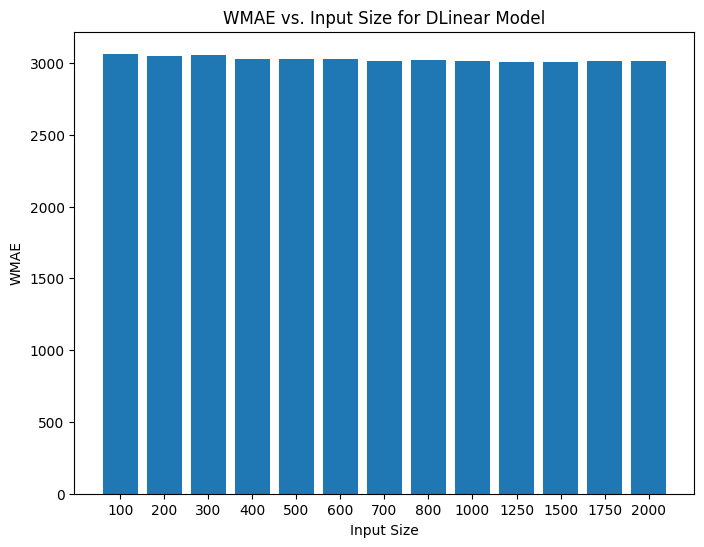

In [ ]:
input_sizes = list(val_results_per_size.keys())
wmae_values = list(val_results_per_size.values())

plt.figure(figsize=(8, 6))
plt.bar([str(s) for s in input_sizes], wmae_values)
plt.xlabel("Input Size")
plt.ylabel("WMAE")
plt.title("WMAE vs. Input Size for DLinear Model")
plt.show()
#used the plots to determine the best value

# **Best learning_rate parameter Search**

In [ ]:
lrs = [5e-2, 3e-2, 1e-2, 5e-3, 3e-3,1e-3, 5e-4, 3e-4 , 1e-4, 5e-5, 3e-5 ,1e-5]
val_results_per_size = {}

for lr in lrs:
  # run name
  run_name = f"DLinear_bestParamSearch_lr:{lr}"
  wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,  # allow multiple in the same script
        config={"input_size": 48, # gotten from the previous section
                "lr" : lr

                })
  # model
  dlinear = DLinear(
        h=forecast_horizon,
        input_size=48,
        loss=MAE(),
        learning_rate=lr,
        max_steps=1000,
        val_check_steps=100,
        early_stop_patience_steps=0,
        scaler_type='robust',
        enable_progress_bar=True,
    )
  #train
  nf = NeuralForecast(models=[dlinear], freq='W')

  log_params(dlinear, static_vars, dynamic_vars)

  print(f"▶️  Training run={run_name} …")
  nf.fit(df=train_formatted, static_df=static_df, val_size=0)
  #metrics
  val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
    )

  val_results_per_size[lr] = val_metrics['WMAE']

  wandb.finish()



INFO:lightning_fabric.utilities.seed:Seed set to 1


▶️  Training run=DLinear_bestParamSearch_lr:[0.05, 0.03, 0.01, 0.005, 0.003, 0.001, 0.0005, 0.0003, 0.0001, 5e-05, 3e-05, 1e-05] …


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 1.8 K  | train
5 | linear_season | Linear        | 1.8 K  | train
--------------------------------------------------------
3.6 K     Trainable params
0         Non-trainable params
3.6 K     Total params
0.015     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=2973.2292  RMSE=6361.7870  WMAE=3064.1905


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,2973.22922
val/RMSE,6361.787
val/WMAE,3064.1905


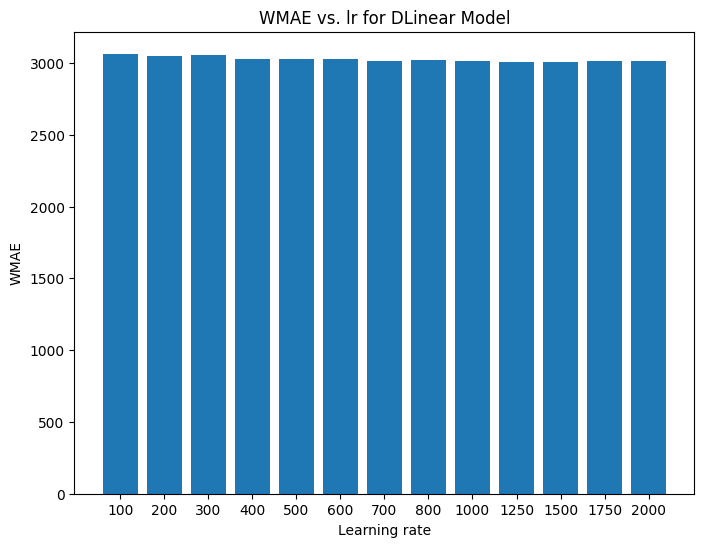

In [ ]:
lr = list(val_results_per_size.keys())
wmae_values = list(val_results_per_size.values())

plt.figure(figsize=(8, 6))
plt.bar([str(s) for s in lr], wmae_values)
plt.xlabel("Learning rate")
plt.ylabel("WMAE")
plt.title("WMAE vs. lr for DLinear Model")
plt.show()

# **Best Max_steps param Search**

In [ ]:
max_steps = [100, 200, 300, 400, 500, 600, 700, 800 ,1000, 1250, 1500, 1750,2000]
val_results_per_size = {}

for max_step in max_steps:
  # run name
  run_name = f"DLinear_bestParamSearch_maxSteps={max_step}"
  wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,  # allow multiple in the same script
        config={"input_size": 48,
                "lr" : 0.001, # gotten from prevoius run
                "max_steps":max_step

                })
  # model
  dlinear = DLinear(
        h=forecast_horizon,
        input_size=48,
        loss=MAE(),
        learning_rate=0.001,
        max_steps=max_step,
        val_check_steps=100,
        early_stop_patience_steps=0,
        scaler_type='robust',
        enable_progress_bar=True,
    )

  nf = NeuralForecast(models=[dlinear], freq='W')

  log_params(dlinear, static_vars, dynamic_vars)

  print(f"▶️  Training run={run_name} …")
  nf.fit(df=train_formatted, static_df=static_df, val_size=0)

  val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
    )

  val_results_per_size[max_step] = val_metrics['WMAE']

  wandb.finish()



INFO:lightning_fabric.utilities.seed:Seed set to 1


▶️  Training run=DLinear_bestParamSearch_maxSteps=100 …


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 1.8 K  | train
5 | linear_season | Linear        | 1.8 K  | train
--------------------------------------------------------
3.6 K     Trainable params
0         Non-trainable params
3.6 K     Total params
0.015     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=1680.7701  RMSE=3641.7002  WMAE=1682.6258


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,1680.77008
val/RMSE,3641.70016
val/WMAE,1682.6258


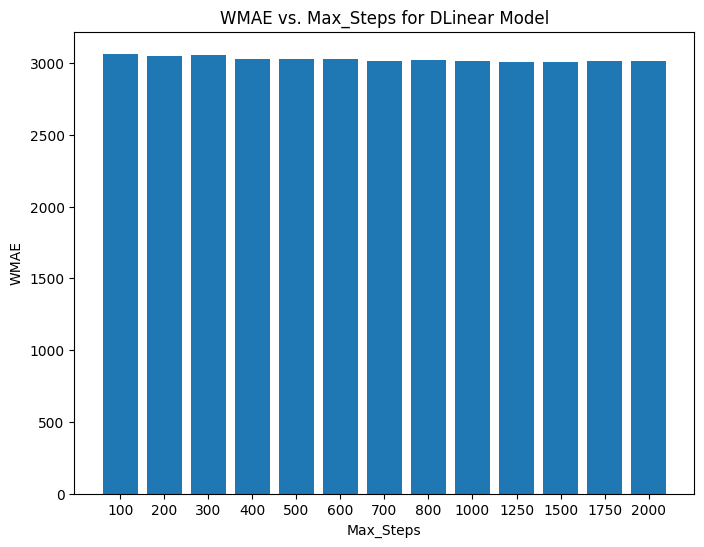

In [ ]:
steps = list(val_results_per_size.keys())
wmae_values = list(val_results_per_size.values())

plt.figure(figsize=(8, 6))
plt.bar([str(s) for s in steps], wmae_values)
plt.xlabel("Max_Steps")
plt.ylabel("WMAE")
plt.title("WMAE vs. Max_Steps for DLinear Model")
plt.show()

# **Best Window_size Search**

In [ ]:
moving_avg_window = [5, 10, 15, 20, 25, 30, 35, 40]
val_results_per_size = {}

for window in moving_avg_window:
  # run name
  run_name = f"DLinear_bestParamSearch_WindowSize:{window}"
  wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,  # allow multiple in the same script
        config={"input_size": 48,
                "lr" : 0.001, # gotten from prevoius run
                "max_steps": 1750,
                "window_size": window

                })
  # model
  dlinear = DLinear(
        h=forecast_horizon,
        input_size=48,
        loss=MAE(),
        learning_rate=0.001,
        max_steps=1750,
        val_check_steps=100,
        early_stop_patience_steps=0,
        scaler_type='robust',
        enable_progress_bar=True,
    )

  nf = NeuralForecast(models=[dlinear], freq='W')

  log_params(dlinear, static_vars, dynamic_vars)

  print(f"▶️  Training run={run_name} …")
  nf.fit(df=train_formatted, static_df=static_df, val_size=0)

  val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
    )

  val_results_per_size[max_step] = val_metrics['WMAE']

  wandb.finish()



INFO:lightning_fabric.utilities.seed:Seed set to 1


▶️  Training run=DLinear_bestParamSearch_WindowSize:5 …


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 1.8 K  | train
5 | linear_season | Linear        | 1.8 K  | train
--------------------------------------------------------
3.6 K     Trainable params
0         Non-trainable params
3.6 K     Total params
0.015     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1750` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=1677.2041  RMSE=3630.7453  WMAE=1682.0143


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,1677.2041
val/RMSE,3630.74532
val/WMAE,1682.01426


In [ ]:
windows = list(val_results_per_size.keys())
wmae_values = list(val_results_per_size.values())

plt.figure(figsize=(8, 6))
plt.bar([str(s) for s in windows], wmae_values)
plt.xlabel("Window_Size")
plt.ylabel("WMAE")
plt.title("WMAE vs. Window_Size for DLinear Model")
plt.show()
# the Window Size change didnt have any effect on the model

# **Save Best Model**

In [ ]:
wandb.init(
    project="ML_Final",
    name="best_dlinear_model",
    config={
        "model": "DLinear",
        "input_size": 48,
        "lr": 0.001,
        "max_steps": 1750,
        "horizon": forecast_horizon,
        "loss": "MAE"

    }
)
models = [
    DLinear(
        h=forecast_horizon,
        input_size=48,
        loss=MAE(),
        learning_rate=0.001,
        max_steps=1750,
        moving_avg_window=13,
        val_check_steps=100,
        early_stop_patience_steps=0,
        scaler_type='robust',
        enable_progress_bar=True,
    )
]

nf = NeuralForecast(
    models=models,
    freq='W'
)

nf.fit(
    df=train_formatted,
    static_df=static_df,
    val_size=0
)


model_path = "best_dlinear_model.pth"
nf.save(path=model_path)

wandb.save(model_path)  # Save to wandb

artifact = wandb.Artifact("dlinear-best-model", type="model")
artifact.add_dir(model_path)
wandb.log_artifact(artifact)

wandb.finish()



# **For submission**

In [ ]:
features_interp = TrendInterpolator().fit_transform(features)
cleaning_pipeline = Pipeline([
    ("merge",       BaseMerger(features_interp, stores)),
    ("fill_markdowns", MarkdownFiller()),
    ("encode",      CategoricalEncoder())
])

feature_pipeline = Pipeline([
    ("stats",       StatisticalSalesFeatures()),
    ("seasonal",    AdvancedSeasonalFeatures()),
    ("econ",        EconomicInteractionFeatures()),
])

train_clean = cleaning_pipeline.fit_transform(train)
test_clean = cleaning_pipeline.transform(test)
train_df = feature_pipeline.fit_transform(train_clean)
test_df = feature_pipeline.transform(test_clean)

train_formatted = prepare_df_for_nf(train_df, True)
test_formatted = prepare_df_for_nf(test_df, False)

static_vars = [ 'Store', 'Dept', 'Type', 'Size',
    'store_mean_sales', 'store_std_sales', 'store_median_sales',
    'dept_mean_sales', 'dept_std_sales', 'dept_median_sales',
    'sd_mean_sales', 'sd_std_sales', 'sd_median_sales'
    ]

dynamic_vars = ['IsHoliday', 'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Day', 'Month', 'Year',
    'month_sin', 'month_cos', 'week_sin', 'week_cos',
    'Days_to_Thanksgiving', 'Days_to_Christmas',
    'days_since_thanksgiving', 'days_since_christmas',
    'thanksgiving_period_flag', 'christmas_period_flag',
    'superbowl_period_flag', 'labor_day_period_flag',
    'pre_thanksgiving_intensity', 'pre_christmas_intensity',
    'post_holiday_effect', 'economic_pressure', 'purchasing_power',
    'total_markdown', 'markdown_count', 'avg_markdown',
    'holiday_markdown_boost'
]

wandb.login()

# Load artifact
run = wandb.init(project="ML_Final")
artifact = run.use_artifact("dlinear-best-model:latest", type="model")
artifact_dir = artifact.download()

# Load model from the downloaded directory
nf = NeuralForecast.load(path=artifact_dir)

prediction = nf.predict(df=train_formatted)

preds = prediction.copy()

# 1) First map Sundays → the preceding Friday
preds['ds'] = preds['ds'] - pd.to_timedelta((preds['ds'].dt.weekday - 4) % 7, unit='d')

# 2) Then shift everything ahead by 7 days so your first pred is 2012-11-02
preds['ds'] = preds['ds'] + pd.Timedelta(days=7)

# Quick check
print(preds['ds'].min(), preds['ds'].max())
preds.head(), test_formatted[['ds']].drop_duplicates().head()

# 1. Prepare test key frame
test_df = test_formatted[['unique_id', 'ds']].copy()

# 2. Merge predictions into test
sub = (
    test_df
    .merge(preds[['unique_id', 'ds', 'DLinear']],
           on=['unique_id', 'ds'], how='left')
    .rename(columns={'DLinear': 'Weekly_Sales'})
)

# 3. Recover Store and Dept from unique_id
sub[['Dept', 'Store']] = sub['unique_id'].str.split('_', expand=True)
sub['Store'] = sub['Store'].astype(int)
sub['Dept']  = sub['Dept'].astype(int)

# 4. Compute store-level mean Weekly_Sales from training data
store_means = train_df_clean.groupby('Store')['Weekly_Sales'].mean()

# 5. Fill missing forecasts with the corresponding Store mean
sub['Weekly_Sales'] = sub['Weekly_Sales'].fillna(sub['Store'].map(store_means))

sub['Id'] = (
    sub['Store'].astype(str) + '_' +
    sub['Dept'].astype(str)  + '_' +
    sub['ds'].dt.strftime('%Y-%m-%d')
)


submission = sub[['Id', 'Weekly_Sales']]
submission.to_csv('DLinear_Best.csv', index=False)
print(f"Saved DLinear_Best.csv with {len(submission)} rows.")

submission.head()


In [30]:
submission.head()

,Id,Weekly_Sales
0,1_1_2012-11-02,24762.998047
1,1_1_2012-11-09,22873.347656
2,1_1_2012-11-16,23387.222656
3,1_1_2012-11-23,23860.439453
4,1_1_2012-11-30,22735.687500


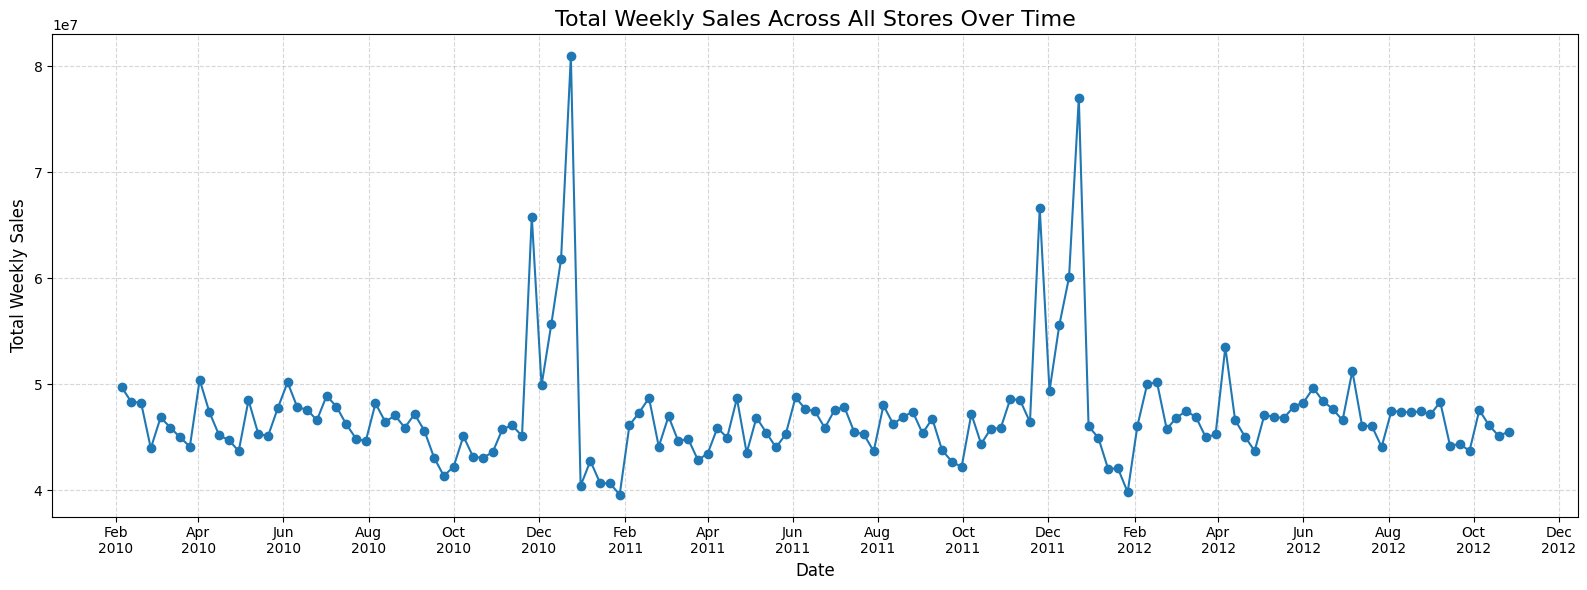

In [32]:
total_sales_per_date = train_df.groupby("Date")["Weekly_Sales"].sum().reset_index()
total_sales_per_date = total_sales_per_date.sort_values("Date")

total_sales_per_date["Date"] = pd.to_datetime(total_sales_per_date["Date"])


plt.figure(figsize=(16, 6))
plt.plot(total_sales_per_date["Date"], total_sales_per_date["Weekly_Sales"], marker='o', linestyle='-')


plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.title("Total Weekly Sales Across All Stores Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Weekly Sales", fontsize=12)
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()